### Case Study: Urban Traffic Flow Optimization

In [183]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [185]:
signal_timings = pd.read_csv('signal_timings_data.csv')
traffic_flow = pd.read_csv('traffic_flow_data.csv')

In [187]:
print("Signal Timings Data:")
print(signal_timings.head())

Signal Timings Data:
     Intersection  Green_Light_Duration  Red_Light_Duration
0  Intersection_1                   107                  87
1  Intersection_2                    41                  47
2  Intersection_3                    43                 119
3  Intersection_4                   111                 115
4  Intersection_5                    56                  85


In [188]:
print("\nTraffic Flow Data:")
print(traffic_flow.head())


Traffic Flow Data:
     Intersection  Hour      Vehicle_Type  Vehicle_Count
0  Intersection_6    20               Car            357
1  Intersection_1     4  Public Transport            308
2  Intersection_4    16       Two-Wheeler            382
3  Intersection_4     3       Company Bus            207
4  Intersection_8     7  Public Transport             59


In [189]:
# Check for missing values
print("\nMissing values in Signal Timings Data:")
print(signal_timings.isnull().sum())

print("\nMissing values in Traffic Flow Data:")
print(traffic_flow.isnull().sum())


Missing values in Signal Timings Data:
Intersection            0
Green_Light_Duration    0
Red_Light_Duration      0
dtype: int64

Missing values in Traffic Flow Data:
Intersection     0
Hour             0
Vehicle_Type     0
Vehicle_Count    0
dtype: int64


In [191]:
# Merge datasets on 'Intersection' for combined analysis
merged_data = pd.merge(traffic_flow, signal_timings, on='Intersection', how='left')
print("\nMerged Data:")
print(merged_data)


Merged Data:
       Intersection  Hour      Vehicle_Type  Vehicle_Count  \
0    Intersection_6    20               Car            357   
1    Intersection_1     4  Public Transport            308   
2    Intersection_4    16       Two-Wheeler            382   
3    Intersection_4     3       Company Bus            207   
4    Intersection_8     7  Public Transport             59   
..              ...   ...               ...            ...   
235  Intersection_2     5       Company Bus             74   
236  Intersection_1     8  Public Transport            144   
237  Intersection_4    11       Company Bus            436   
238  Intersection_9    14       Company Bus            389   
239  Intersection_9     0       Company Bus            437   

     Green_Light_Duration  Red_Light_Duration  
0                     100                  98  
1                     107                  87  
2                     111                 115  
3                     111                 115  
4

## Exploratory Data Analysis (EDA)


### 1. Traffic Flow Analysis


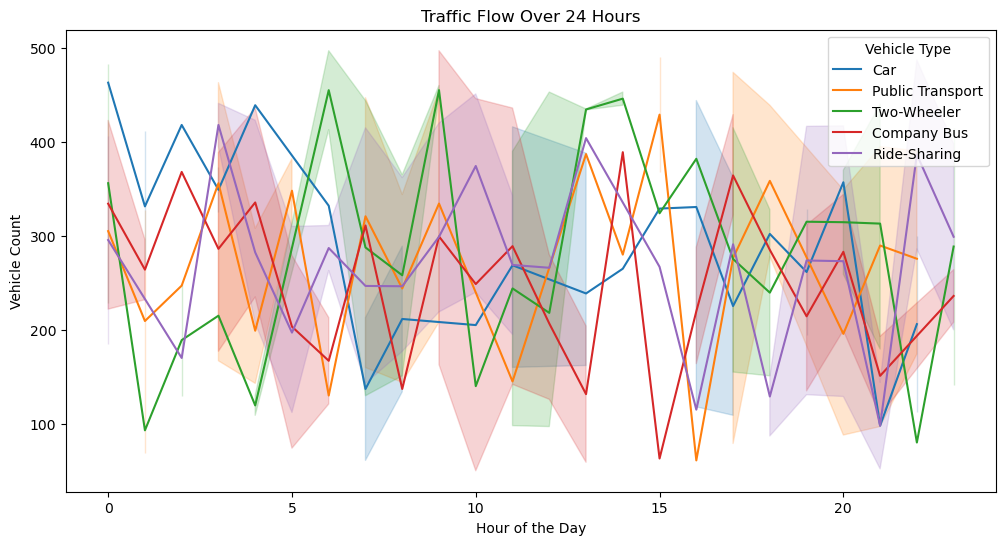

In [196]:
# Plot traffic flow over 24 hours
plt.figure(figsize=(12, 6))
sns.lineplot(data=traffic_flow, x='Hour', y='Vehicle_Count', hue='Vehicle_Type')
plt.title('Traffic Flow Over 24 Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Vehicle Count')
plt.legend(title='Vehicle Type')
plt.show()

### 2. Peak Hour Analysis

In [199]:
hourly_traffic = traffic_flow.groupby('Hour')['Vehicle_Count'].sum().reset_index()
print(hourly_traffic)

    Hour  Vehicle_Count
0      0           3742
1      1           2243
2      2           1581
3      3           4534
4      4           3464
5      5           1897
6      6           2280
7      7           4367
8      8           2303
9      9           3708
10    10           2214
11    11           2555
12    12           1540
13    13           2639
14    14           1826
15    15           1841
16    16           2209
17    17           4028
18    18           2170
19    19           3219
20    20           3534
21    21           2717
22    22           2643
23    23           2513


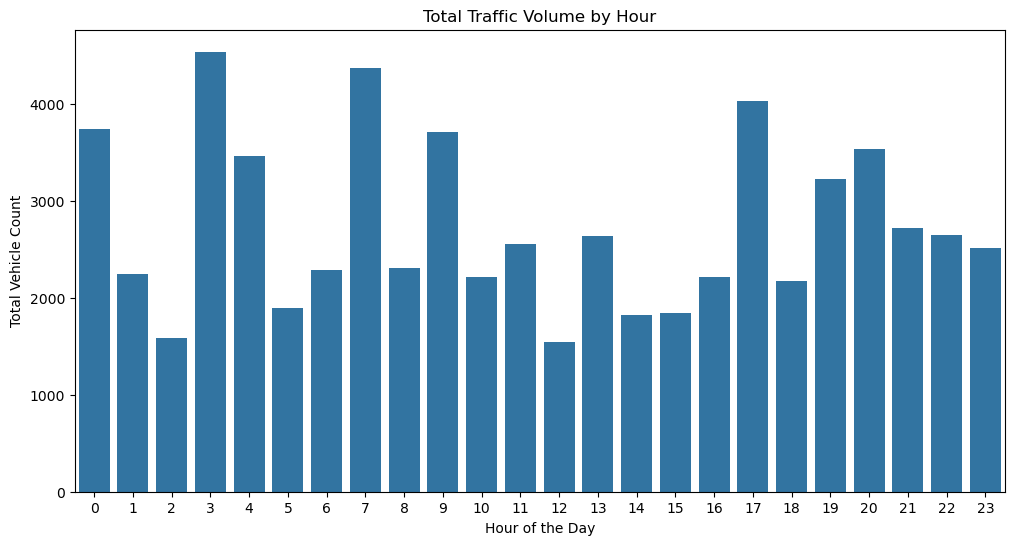

In [200]:
# Calculate total traffic per hour
hourly_traffic = traffic_flow.groupby('Hour')['Vehicle_Count'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_traffic, x='Hour', y='Vehicle_Count')
plt.title('Total Traffic Volume by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Vehicle Count')
plt.show()

## 3. Signal Timing Analysis

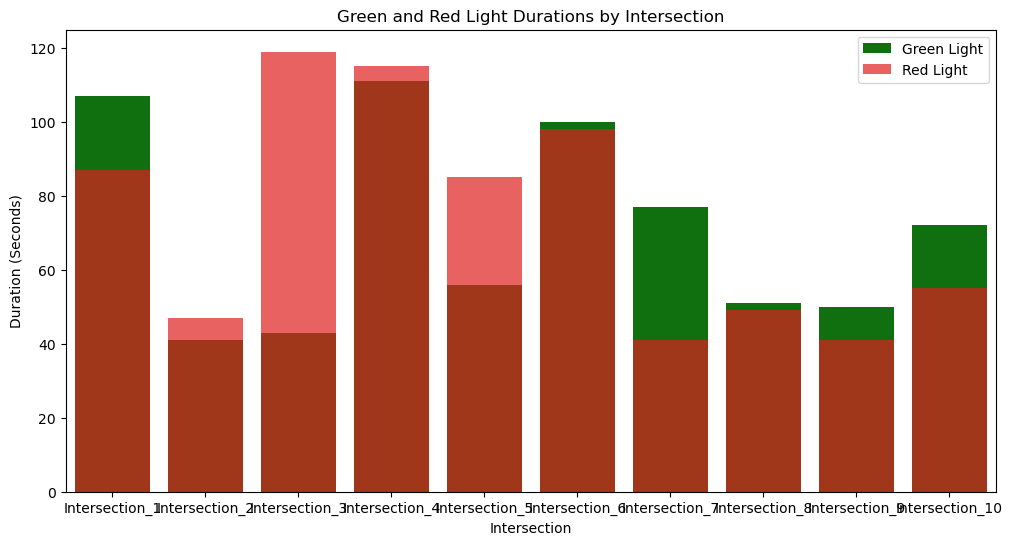

In [202]:
# Plot green and red light durations by intersection
plt.figure(figsize=(12, 6))
sns.barplot(data=signal_timings, x='Intersection', y='Green_Light_Duration', color='green', label='Green Light')
sns.barplot(data=signal_timings, x='Intersection', y='Red_Light_Duration', color='red', label='Red Light', alpha=0.7)  
plt.title('Green and Red Light Durations by Intersection')
plt.xlabel('Intersection')
plt.ylabel('Duration (Seconds)')
plt.legend()
plt.show()

## 4. Correlation Between Traffic Flow and Signal Timings


In [204]:
# Calculate average traffic flow per intersection
avg_traffic_per_intersection = traffic_flow.groupby('Intersection')['Vehicle_Count'].mean().reset_index()

In [205]:
# Merge with signal timings
signal_traffic_correlation = pd.merge(avg_traffic_per_intersection, signal_timings, on='Intersection', how='left')

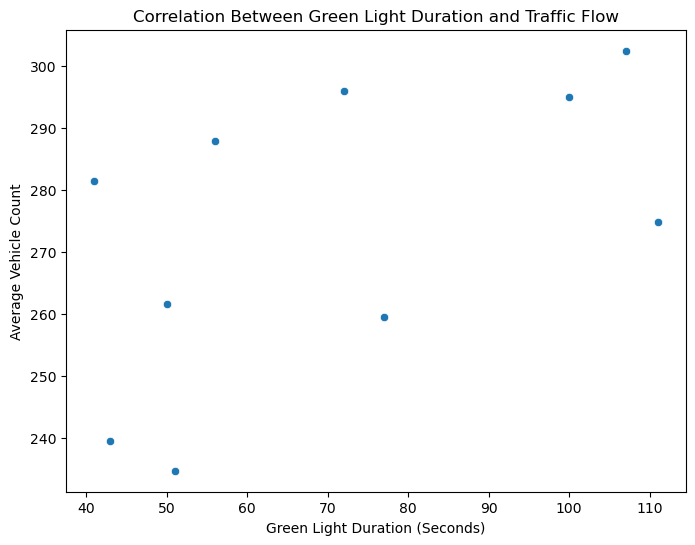

In [206]:
# Plot correlation between traffic flow and green light duration
plt.figure(figsize=(8, 6))
sns.scatterplot(data=signal_traffic_correlation, x='Green_Light_Duration', y='Vehicle_Count')
plt.title('Correlation Between Green Light Duration and Traffic Flow')
plt.xlabel('Green Light Duration (Seconds)')
plt.ylabel('Average Vehicle Count')
plt.show()

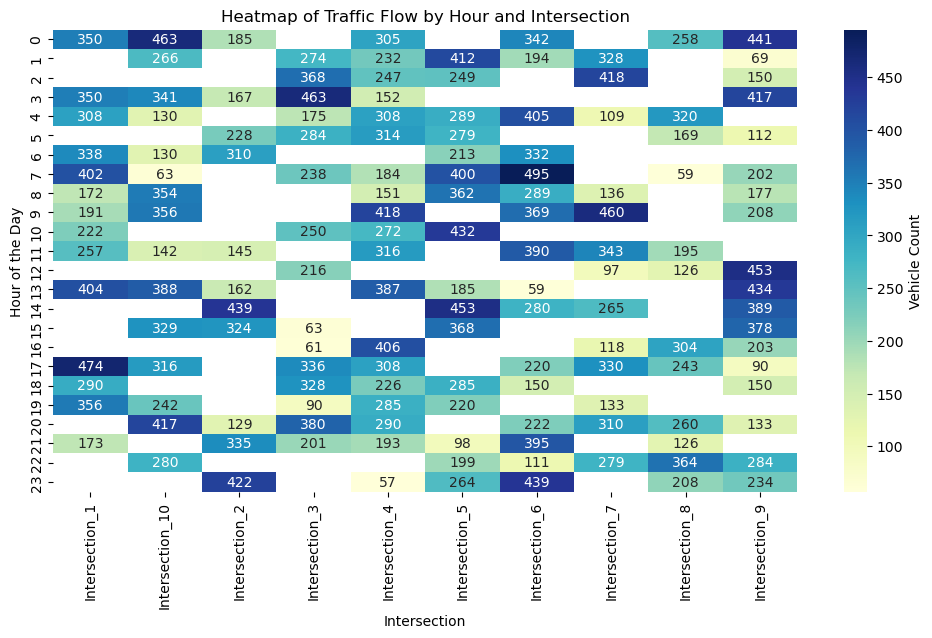

In [207]:
heatmap_data = merged_data.pivot_table(
    index='Hour', 
    columns='Intersection', 
    values=['Vehicle_Count', 'Green_Light_Duration'],
    aggfunc='mean'  # Use the mean to handle multiple rows for the same hour and intersection
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data['Vehicle_Count'], annot=True, cmap='YlGnBu', fmt=".0f", cbar_kws={'label': 'Vehicle Count'})
plt.title('Heatmap of Traffic Flow by Hour and Intersection')
plt.xlabel('Intersection')
plt.ylabel('Hour of the Day')
plt.show()

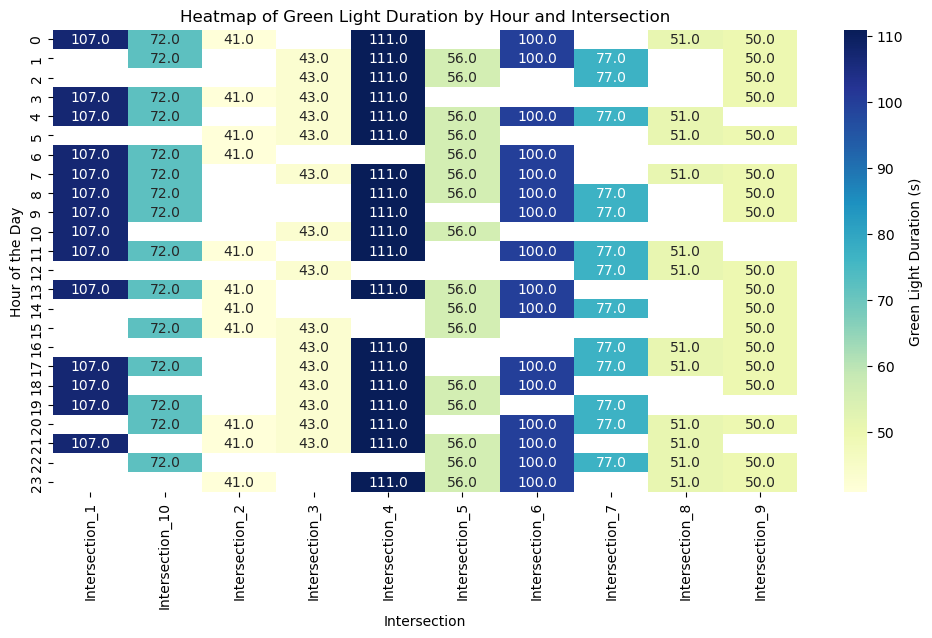

In [208]:
# Create a heatmap for green light duration
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data['Green_Light_Duration'], annot=True, cmap='YlGnBu', fmt=".1f", cbar_kws={'label': 'Green Light Duration (s)'})
plt.title('Heatmap of Green Light Duration by Hour and Intersection')
plt.xlabel('Intersection')
plt.ylabel('Hour of the Day')
plt.show()

## Optimization Suggestions

In [210]:
# 1. Adjust Signal Timings Based on Traffic Flow
# Identify intersections with high traffic but low green light duration
high_traffic_intersections = signal_traffic_correlation[signal_traffic_correlation['Vehicle_Count'] > signal_traffic_correlation['Vehicle_Count'].median()]
low_green_intersections = high_traffic_intersections[high_traffic_intersections['Green_Light_Duration'] < high_traffic_intersections['Green_Light_Duration'].median()]

print("\nIntersections with High Traffic but Low Green Light Duration:")
print(low_green_intersections[['Intersection', 'Vehicle_Count', 'Green_Light_Duration']])


Intersections with High Traffic but Low Green Light Duration:
     Intersection  Vehicle_Count  Green_Light_Duration
2  Intersection_2     281.411765                    41
5  Intersection_5     287.863636                    56


In [211]:
# 2. Implement Adaptive Traffic Control Systems
# Suggest intersections for adaptive traffic control
adaptive_control_candidates = low_green_intersections['Intersection'].tolist()
print("\nSuggested Intersections for Adaptive Traffic Control Systems:")
print(adaptive_control_candidates)


Suggested Intersections for Adaptive Traffic Control Systems:
['Intersection_2', 'Intersection_5']


In [212]:
# 3. Promote Public Transport and Ride-Sharing
# Analyze the proportion of public transport and ride-sharing vehicles
public_transport_flow = traffic_flow[traffic_flow['Vehicle_Type'].isin(['Public Transport', 'Ride-Sharing Services'])]
public_transport_percentage = public_transport_flow['Vehicle_Count'].sum() / traffic_flow['Vehicle_Count'].sum() * 100

print(f"\nPercentage of Public Transport and Ride-Sharing Vehicles: {public_transport_percentage:.2f}%")
if public_transport_percentage < 30:
    print("Consider promoting public transport and ride-sharing to reduce private vehicle usage.")


Percentage of Public Transport and Ride-Sharing Vehicles: 19.16%
Consider promoting public transport and ride-sharing to reduce private vehicle usage.


##  Predicting Traffic Flow (using existing features)

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Assuming hourly_traffic contains 'Hour' and 'Vehicle_Count'
# Features and target variable
X = hourly_traffic[['Hour']]  # Feature: Hour
y = hourly_traffic['Vehicle_Count']  # Target: Vehicle_Count

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the traffic flow for each hour from 0 to 24
hourly_predictions = []

for hour in range(25):  # Loop through hours 0 to 24
    # Predict the vehicle count for each hour
    predicted_flow = model.predict([[hour]])
    hourly_predictions.append(predicted_flow[0])




C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\ajith\anaconda3\Lib\site-packages\sklearn\base.py:493: U

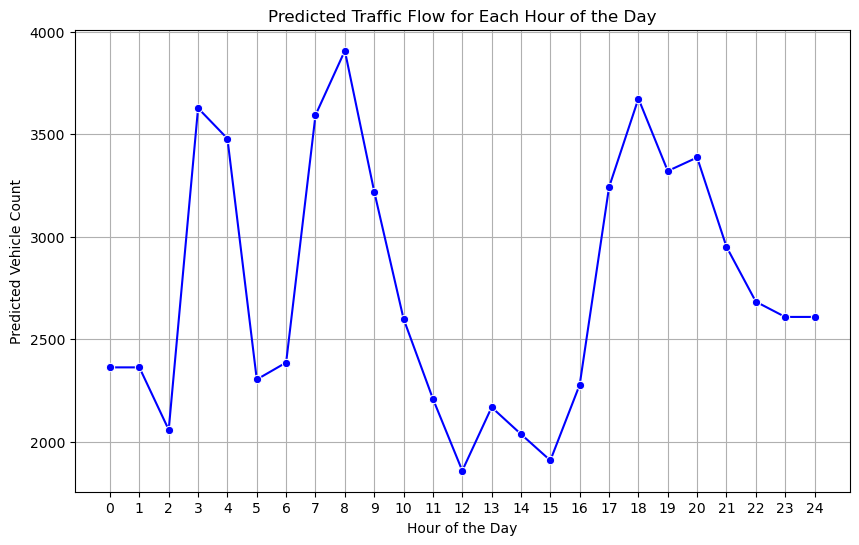

In [215]:
# Plot the predicted traffic flow as a line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(25), y=hourly_predictions, marker='o', color='b')

# Adding titles and labels
plt.title('Predicted Traffic Flow for Each Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Predicted Vehicle Count')
plt.xticks(range(25))  # Ensure x-axis has values from 0 to 24
plt.grid(True)
plt.show()

## Optimizing Signal Timings Dynamically


Optimized Signal Timings for Each Hour:
    Hour  Green Light Duration  Red Light Duration
0      0             82.403975           86.917627
1      1             82.403975           86.917627
2      2             80.908044           85.213672
3      3             88.618630           83.848247
4      4             87.888693           83.432526
5      5             82.114093           86.587434
6      6             82.519367           87.049067
7      7             88.450969           83.752759
8      8             89.994943           84.632099
9      9             86.618145           82.708911
10    10             83.568022           88.243548
11    11             81.650311           86.059159
12    12             79.926493           84.095626
13    13             81.447379           85.828007
14    14             80.803459           85.094543
15    15             80.172605           84.375963
16    16             81.988433           86.444300
17    17             86.723958           

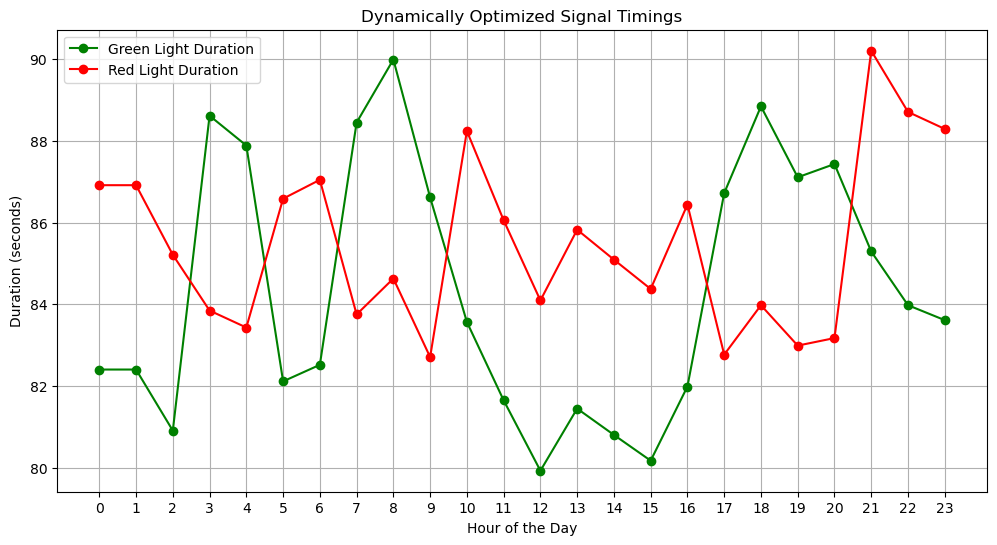

In [309]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate mean and standard deviation for vehicle count and signal durations
mean_traffic = hourly_traffic['Vehicle_Count'].mean()
std_traffic = hourly_traffic['Vehicle_Count'].std()

mean_green_duration = signal_timings['Green_Light_Duration'].mean()
std_green_duration = signal_timings['Green_Light_Duration'].std()

mean_red_duration = signal_timings['Red_Light_Duration'].mean()
std_red_duration = signal_timings['Red_Light_Duration'].std()

# Convert predictions to a dictionary for efficient lookup
hourly_predictions_dict = dict(enumerate(hourly_predictions))

# Function to compute optimized signal timings
def optimize_signal_timing(row):
    hour = row['Hour']
    predicted_flow = hourly_predictions_dict.get(hour, mean_traffic)  # Default to mean if missing
    current_vehicle_count = row['Vehicle_Count']
    
    # Compute traffic ratio
    traffic_ratio = predicted_flow / mean_traffic if mean_traffic > 0 else 1  # Avoid division by zero

    # Adjust green and red light durations based on traffic ratio
    if predicted_flow > mean_traffic + 0.5 * std_traffic:
        green_duration = mean_green_duration + 0.5 *(traffic_ratio * std_green_duration)
        red_duration = mean_red_duration +0.25*(traffic_ratio * std_red_duration)
    elif predicted_flow < mean_traffic - 0.5 * std_traffic:
        green_duration = mean_green_duration +0.5*(traffic_ratio * std_green_duration)
        red_duration = mean_red_duration + 0.5*(traffic_ratio * std_red_duration)
    else:
        green_duration = mean_green_duration + (0.5 * traffic_ratio * std_green_duration)
        red_duration = mean_red_duration + (0.5 * traffic_ratio * std_red_duration)

    return pd.Series({'Green Light Duration': green_duration, 'Red Light Duration': red_duration})

# Apply function to hourly traffic data
hourly_traffic[['Green Light Duration', 'Red Light Duration']] = hourly_traffic.apply(optimize_signal_timing, axis=1)

# Compute overall optimum durations
optimum_green_duration = hourly_traffic['Green Light Duration'].mean()
optimum_red_duration = hourly_traffic['Red Light Duration'].mean()

# Display optimized signal timings
print("\nOptimized Signal Timings for Each Hour:")
print(hourly_traffic[['Hour', 'Green Light Duration', 'Red Light Duration']])

# Convert results into dictionary if needed
optimized_signal_timings = hourly_traffic.set_index('Hour')[['Green Light Duration', 'Red Light Duration']].to_dict('index')

# Plot Green and Red light durations vs Hours
plt.figure(figsize=(12, 6))
plt.plot(hourly_traffic['Hour'], hourly_traffic['Green Light Duration'], marker='o', linestyle='-', color='green', label='Green Light Duration')
plt.plot(hourly_traffic['Hour'], hourly_traffic['Red Light Duration'], marker='o', linestyle='-', color='red', label='Red Light Duration')

plt.xlabel('Hour of the Day')
plt.ylabel('Duration (seconds)')
plt.title('Dynamically Optimized Signal Timings')
plt.xticks(hourly_traffic['Hour'])
plt.grid(True)
plt.legend()
plt.show()

